Đọc file 'healthcare-dataset-stroke-data.csv' bằng thư viện pandaspandas

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\GIT\GROUP__3\DATA\healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Giải thích ý nghĩa các cột trong tập dữ liệu**

| Tên cột              | Ý nghĩa |
|----------------------|--------|
| `id`                 | Mã định danh duy nhất của mỗi cá nhân |
| `gender`             | Giới tính của cá nhân (`Male`, `Female`, hoặc `Other`) |
| `age`                | Tuổi của cá nhân (tính theo năm) |
| `hypertension`       | Tăng huyết áp (0 = Không, 1 = Có) |
| `heart_disease`      | Bệnh tim (0 = Không, 1 = Có) |
| `ever_married`       | Đã từng kết hôn hay chưa (`Yes`, `No`) |
| `work_type`          | Loại hình công việc (`Private`, `Self-employed`, `Govt_job`, `children`, `Never_worked`) |
| `Residence_type`     | Loại nơi cư trú (`Urban` = thành thị, `Rural` = nông thôn) |
| `avg_glucose_level`  | Mức đường huyết trung bình (mg/dL) |
| `bmi`                | Chỉ số khối cơ thể (Body Mass Index) |
| `smoking_status`     | Tình trạng hút thuốc (`formerly smoked`, `never smoked`, `smokes`, `Unknown`) |
| `stroke`             | Đã từng bị đột quỵ hay chưa (0 = Không, 1 = Có) |


# 1. PHÂN TÍCH SƠ BỘ DỮ LIỆU

Hiểu cấu trúc dữ liệu

In [ ]:
print(f'Số dòng: {df.shape[0]}')
print(f'Số cột: {df.shape[1]}')

Số dòng : 5110
Số cột: 12


In [4]:
# Liệt kê các cột và xem kiểu dữ liệu 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [ ]:
# thống kê mô tả bộ dữ liệu dạng số
print(df.describe())

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.100000     0

## Tổng quan thống kê mô tả

Bảng thống kê mô tả dưới đây phản ánh các đặc trưng cơ bản của bộ dữ liệu bệnh nhân, bao gồm 7 biến định lượng và 3 biến nhị phân. Dưới đây là phân tích chi tiết:

### Biến định danh (id)

Không có ý nghĩa phân tích thống kê, được sử dụng để định danh từng cá thể.

Phân bố ID trải đều từ 67 đến 72940, không cần xử lý thêm.

### Tuổi (age)

- Trung bình: 43.23 tuổi  
- Độ lệch chuẩn (std): 22.61  
- Giá trị nhỏ nhất: 0.08 tuổi (khoảng 1 tháng) — cần kiểm tra xem có phải dữ liệu bất thường không  
- Phân vị:
  - 25% ≤ 25 tuổi
  - 75% ≤ 61 tuổi  
  → Phân bố có vẻ lệch phải (phần lớn là người trẻ)

### Tăng huyết áp (hypertension) & Bệnh tim (heart_disease)

- Là các biến nhị phân (0/1)
- Tỷ lệ người bị tăng huyết áp: ~9.75%  
- Tỷ lệ người mắc bệnh tim: ~5.4%  
→ Tỷ lệ này khá thấp, phân bố mất cân bằng, cần lưu ý nếu xây dựng mô hình học máy

### Mức đường huyết trung bình (avg_glucose_level)

- Trung bình: 106.15 mg/dL  
- Độ lệch chuẩn: 45.28  
- Giá trị tối đa: 271.74 — có thể là outlier  
- 75% dữ liệu ≤ 114.09  
→ Phân bố có dấu hiệu lệch phải, nên chuẩn hóa hoặc biến đổi log nếu dùng trong mô hình

### Chỉ số BMI (bmi)

- Trung bình: 28.89 — nằm trong ngưỡng tiền béo phì theo chuẩn WHO  
- Số lượng quan sát hợp lệ: 4909/5110 → khoảng 3.9% thiếu dữ liệu  
- Giá trị tối đa: 97.6 — cao bất thường, khả năng là outlier  
→ Cần xử lý missing values và kiểm tra outliers

### Đột quỵ (stroke)

- Biến mục tiêu nhị phân  
- Tỷ lệ đột quỵ: 4.87%  
→ Class imbalance nghiêm trọng, cần các kỹ thuật xử lý như oversampling, SMOTE, hoặc điều chỉnh trọng số trong mô hình

## Kết luận

- **Kiểm tra outliers**: đặc biệt ở các biến `age`, `avg_glucose_level`, `bmi`
- **Xử lý missing values**: biến `bmi` cần bổ sung hoặc ước lượng dữ liệu thiếu
- **Xử lý class imbalance**: biến mục tiêu `stroke` cần được cân bằng bằng các kỹ thuật phù hợp
- **Chuẩn hóa dữ liệu**: nên thực hiện chuẩn hóa hoặc feature scaling với các biến định lượng để đảm bảo hiệu quả mô hình hóa

In [7]:
# thống kê mô tả cho các cột kiểu object
df_catogery = df.describe(include=[object,'category'])
df_catogery

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [9]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [11]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

In [13]:
df['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [15]:
gender = df['gender'].value_counts().reset_index(name = "Số lượng")
gender

,gender,Số lượng
0,Female,2994
1,Male,2115
2,Other,1


In [21]:
ever_married = df['ever_married'].value_counts().reset_index(name = "Số lượng")
ever_married

,ever_married,Số lượng
0,Yes,3353
1,No,1757


In [22]:
work_type = df['work_type'].value_counts().reset_index(name = "Số lượng")
work_type

,work_type,Số lượng
0,Private,2925
1,Self-employed,819
2,children,687
3,Govt_job,657
4,Never_worked,22


In [23]:
Residence_type = df['Residence_type'].value_counts().reset_index(name = "Số lượng")
Residence_type

,Residence_type,Số lượng
0,Urban,2596
1,Rural,2514


In [24]:
smoking_status = df['smoking_status'].value_counts().reset_index(name = "Số lượng")
smoking_status

,smoking_status,Số lượng
0,never smoked,1892
1,Unknown,1544
2,formerly smoked,885
3,smokes,789


Phân tích giá trị thiếu

In [25]:
# kiểm tra giá trị thiếu
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Hầu hết các trường đều không thiếu chỉ có cột bmi là thiếu 201 giá trị tương ứng với khoảng 4% so với tổng thể.

In [ ]:
# tính tỷ lệ phần trăm thiếu
missing = df.isnull().mean() * 100
missing

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

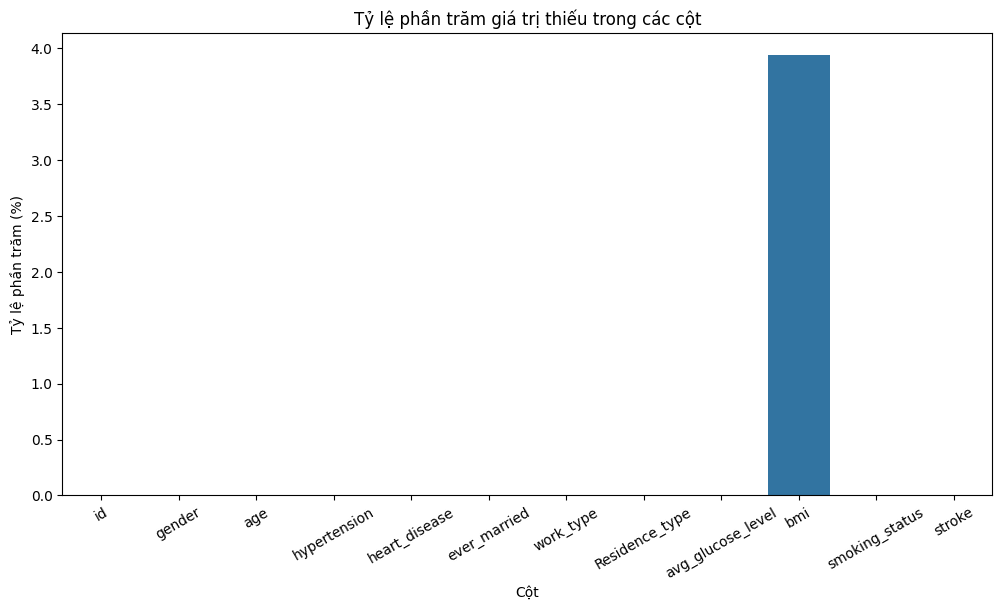

In [29]:
# Visualize giá trị thiếu bằng biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x=missing.index, y=missing.values)
plt.title('Tỷ lệ phần trăm giá trị thiếu trong các cột')
plt.xlabel('Cột')
plt.ylabel('Tỷ lệ phần trăm (%)')
plt.xticks(rotation=30)
plt.show()

Phân tích giá trị ngoại lai

In [31]:
# Lọc các cột số
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Hàm xác định outliers theo IQR
def detect_outliers_iqr(df, cols):
    outlier_dict = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_dict[col] = {
            "số_lượng_ngoại_lai": outliers.shape[0],
            "tỷ_lệ_ngoại_lai": round(100 * outliers.shape[0] / df.shape[0], 2)
        }
    return pd.DataFrame(outlier_dict).T

# Áp dụng
outlier_summary = detect_outliers_iqr(df, numeric_cols)
print(outlier_summary)

                   số_lượng_ngoại_lai  tỷ_lệ_ngoại_lai
id                                0.0             0.00
age                               0.0             0.00
hypertension                    498.0             9.75
heart_disease                   276.0             5.40
avg_glucose_level               627.0            12.27
bmi                             110.0             2.15
stroke                          249.0             4.87


D:\temp\ipykernel_2024\4203350468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


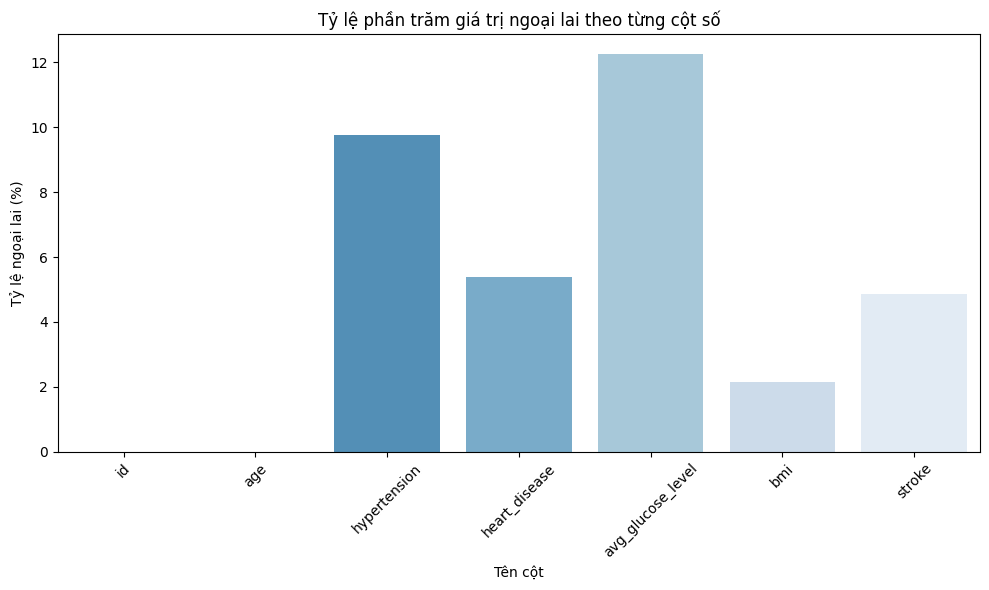

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=outlier_summary.index,
    y='tỷ_lệ_ngoại_lai',
    data=outlier_summary,
    palette='Blues_r'
)
plt.xticks(rotation=45)
plt.title('Tỷ lệ phần trăm giá trị ngoại lai theo từng cột số')
plt.ylabel('Tỷ lệ ngoại lai (%)')
plt.xlabel('Tên cột')
plt.tight_layout()
plt.show()

Phân tích mối quan hệ giữa các biến

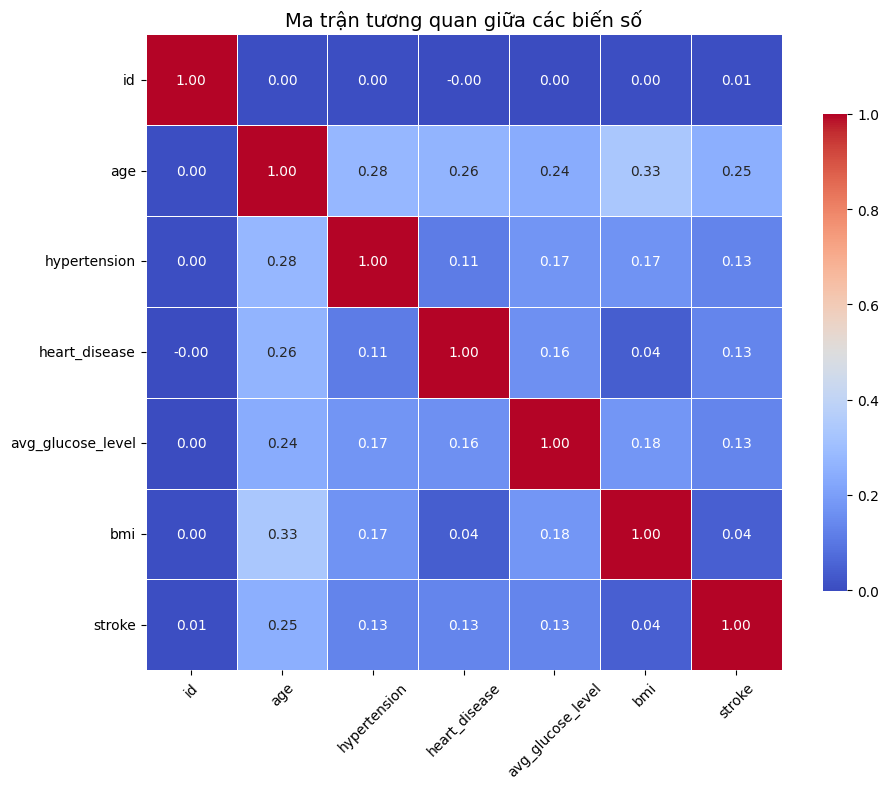

In [36]:
# Tính hệ số tương quan Pearson giữa các cột số
correlation_matrix = df[numeric_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,             # hiển thị giá trị số
    fmt=".2f",              # định dạng số
    cmap='coolwarm',        # màu sắc
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .75}
)
plt.title("Ma trận tương quan giữa các biến số", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Phân tích Ma trận Tương quan

### Tổng quan

Ma trận thể hiện hệ số tương quan Pearson giữa các biến định lượng và nhị phân. Giá trị dao động từ -1 đến 1, trong đó:

- +1: tương quan tuyến tính dương hoàn hảo  
- 0: không có tương quan tuyến tính  
- -1: tương quan tuyến tính âm hoàn hảo  

### Những phát hiện chính

#### Tương quan với biến mục tiêu (`stroke`)

Mọi biến đều có tương quan rất yếu với `stroke`:

- `age`: 0.25 → tương quan dương nhẹ, người lớn tuổi dễ bị đột quỵ hơn  
- `hypertension`, `heart_disease`, `avg_glucose_level`: khoảng 0.13 → có ý nghĩa lâm sàng nhưng rất yếu về mặt thống kê tuyến tính  
- `bmi`: 0.04 → gần như không liên quan

**Nhận định**: Biến mục tiêu `stroke` không có mối liên hệ tuyến tính mạnh với bất kỳ biến nào.  
→ Cần áp dụng mô hình phi tuyến (như tree-based models, XGBoost) hoặc phân tích thêm các mối liên hệ phi tuyến (mutual information, ANOVA,...)

#### Tương quan giữa các biến độc lập

- `age` có tương quan nhẹ với:
  - `bmi`: 0.33  
  - `hypertension`: 0.28  
  - `heart_disease`: 0.26  
  - `avg_glucose_level`: 0.24  

Những mối quan hệ này phản ánh đặc điểm thực tế: tuổi cao thường đi kèm với nguy cơ tăng huyết áp, bệnh tim, béo phì và đường huyết cao.

- Tương quan giữa `hypertension`, `heart_disease`, `avg_glucose_level` đều < 0.2  
→ Các biến tương đối độc lập với nhau, thuận lợi cho mô hình hóa do ít đa cộng tuyến

#### Biến không mang ý nghĩa phân tích

- `id` có tương quan gần như bằng 0 với mọi biến  
→ Là biến định danh, nên loại bỏ khỏi quá trình phân tích

### Kết luận và Khuyến nghị

- Không có biến nào có tương quan tuyến tính mạnh với `stroke`  
→ Cần tiếp cận đa chiều hơn, sử dụng các kỹ thuật khai thác đặc trưng phi tuyến hoặc kết hợp nhiều đặc trưng

- Không có dấu hiệu đa cộng tuyến nghiêm trọng giữa các biến độc lập  
→ Thuận lợi cho việc xây dựng mô hình tuyến tính

### Đề xuất

- Khám phá thêm các mối quan hệ phi tuyến hoặc tương tác biến  
- Áp dụng phương pháp chọn biến (feature selection) như:
  - RFE (Recursive Feature Elimination)  
  - `mutual_info_classif`  
  - Mô hình Random Forest và đánh giá `feature_importance`


Phân tích biến mục tiêu

In [37]:
stroke = df['stroke'].value_counts().reset_index(name = "Số lượng")
stroke

,stroke,Số lượng
0,0,4861
1,1,249


D:\temp\ipykernel_2024\458457356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='Set2')


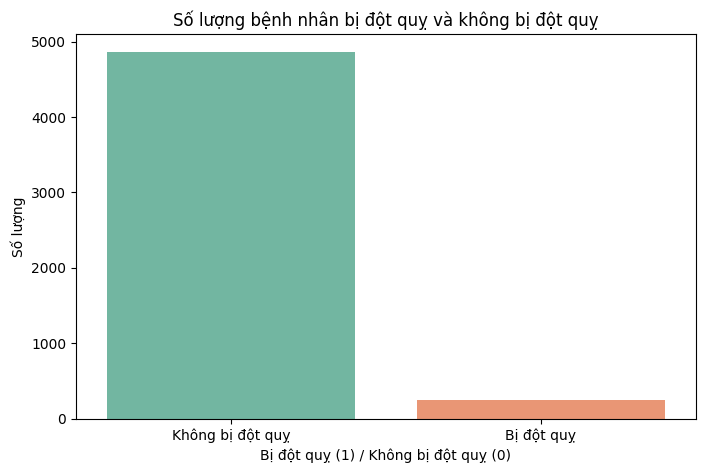

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('Số lượng bệnh nhân bị đột quỵ và không bị đột quỵ')
plt.xlabel('Bị đột quỵ (1) / Không bị đột quỵ (0)')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không bị đột quỵ', 'Bị đột quỵ'])
plt.show()

Kiểm tra giá trị trùng lặp

In [39]:
# kiểm tra trùng lặp 
duplicates = df.duplicated().sum()
print(f'Số lượng dòng trùng lặp: {duplicates}')

Số lượng dòng trùng lặp: 0


# XỬ LÝ DỮ LIỆU

TIỀN XỬ LÝ DỮ LIỆU

In [41]:
# điền giá trị thiếu cho cột 'bmi'
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

D:\temp\ipykernel_2024\3614872547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [42]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [43]:
# xóa cột id vì không có ý nghĩa trong phân tích
df.drop(columns=['id'], inplace=True)

In [44]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [ ]:
# xử lý giá trị ngoại lai
'''Các cột như hypertension, heart_disease, stroke là biến nhị phân (0 hoặc 1) → không nên xử lý ngoại lai bằng IQR vì 1 là giá trị hợp lệ.'''

In [ ]:
def log_clip_column(df, col):
    # Log transform
    log_col = np.log1p(df[col])
    
    # Tính IQR trên biến log
    Q1 = log_col.quantile(0.25)
    Q3 = log_col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Clip(cắt) ngoại lai trên biến log
    log_col_clipped = log_col.clip(lower=lower_bound, upper=upper_bound)
    
    return log_col_clipped

# Áp dụng cho cả 2 cột
df['avg_glucose_level_log'] = log_clip_column(df, 'avg_glucose_level')
df['bmi_log'] = log_clip_column(df, 'bmi')

In [ ]:
# Kiểm tra lại outliers sau khi xử lý

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# gọi lại hàm kiểm tra outliers
outlier_summary_post = detect_outliers_iqr(df, numeric_cols)
print(outlier_summary_post)

                       số_lượng_ngoại_lai  tỷ_lệ_ngoại_lai
age                                   0.0             0.00
hypertension                        498.0             9.75
heart_disease                       276.0             5.40
avg_glucose_level                   627.0            12.27
bmi                                 126.0             2.47
stroke                              249.0             4.87
avg_glucose_level_log                 0.0             0.00
bmi_log                               0.0             0.00


In [59]:
# xóa giá trị other trong cột gender
df = df[df['gender'] != 'Other'].reset_index(drop=True)

In [60]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [62]:
# các cột phân loại cần mã hóa:
categorical_cols = ['gender', 'work_type', 'Residence_type', 'smoking_status']

# Áp dụng one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

### Ưu và nhược điểm của One-Hot Encoding

**Ưu điểm:**
- Không tạo quan hệ thứ tự giả giữa các giá trị phân loại.
- Dễ hiểu, trực quan và phổ biến.
- Phù hợp với nhiều thuật toán học máy.
- Thực hiện nhanh, có sẵn trong pandas và sklearn.

**Nhược điểm:**
- Tăng số chiều dữ liệu, gây tốn bộ nhớ.
- Không hiệu quả với biến phân loại có nhiều giá trị (high cardinality).
- Không thể hiện mối quan hệ gần nhau giữa các nhãn.
- Có thể làm giảm hiệu suất với một số thuật toán do dữ liệu rất nhiều chiều.


In [65]:
# chuẩn hóa cột 'ever_married' về dạng nhị phân
df_encoded['ever_married'] = df_encoded['ever_married'].map({'Yes': 1, 'No': 0})

In [68]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [69]:
df_encoded.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,avg_glucose_level_log,bmi_log,gender_Male,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051242,0,1,1,2.706450,1.001041,1,5.324519,3.627004,True,False,True,False,False,True,True,False,False
1,0.785889,0,0,1,2.121652,-0.000165,1,5.314240,3.397632,False,False,False,True,False,False,False,True,False
2,1.626174,0,1,1,-0.004867,0.468399,1,4.672081,3.511545,True,False,True,False,False,False,False,True,False
3,0.255182,0,0,1,1.437473,0.715233,1,5.148831,3.566712,False,False,True,False,False,True,False,False,True
4,1.581949,1,0,1,1.501297,-0.635858,1,5.165471,3.218876,False,False,False,True,False,False,False,True,False


**Lý do nên dùng StandardScaler**

- **Chuẩn hóa dữ liệu về phân phối chuẩn (mean=0, std=1)** giúp nhiều thuật toán học máy hoạt động hiệu quả hơn (ví dụ: Logistic Regression, SVM, Neural Networks).
- StandardScaler xử lý tốt dữ liệu có phân phối gần chuẩn, làm cho các đặc trưng có cùng thang đo, tránh việc đặc trưng có giá trị lớn chi phối mô hình.
- Các phương pháp khác như MinMaxScaler nhạy cảm với ngoại lai, còn RobustScaler thích hợp khi dữ liệu có nhiều ngoại lai nhưng không phải lúc nào cũng cần thiết.
- Do đó, StandardScaler là lựa chọn phổ biến, phù hợp với nhiều bài toán và mô hình học máy.